In [1]:
import polars as pl

In [2]:
df = pl.read_parquet("final_patient_data.parquet")

In [3]:
df.head(1)

patient_id,hosp_id,centre,hosp_admission_datetime,hosp_discharge_datetime,inclusion_flag,icu_stay_flag,Cardiopathie ischémique,Fibrillation atriale,Insuffisance cardiaque chronique,Pacemaker,Pontage aorto-coronarien,Insuffisance rénale chronique,Antécédent d'AVC,Cirrhose,Cancer actif,Immunodépression,Dyslipidémie,Diabète,beta_blocker,ACEI,ARB,anti_aldosterone,furosemide,gender,birth_date,death_date,age_at_admission,comorbidity_score,hfrs_score,OMT_component_score,death_flag
str,i64,str,datetime[μs],datetime[μs],i64,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,str,date,date,i32,f64,f64,i8,i32
"""P001""",1002,"""angers""",2018-07-04 11:15:00,2018-07-12 10:00:00,1,0,1,1,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,"""F""",1933-04-12,2018-09-21,85,0.0,0.0,2,1


In [4]:
patient = pl.read_parquet("patient.parquet")

In [5]:
df_surv = df.join(patient.select(pl.col(["patient_id", "last_seen_date"])), on = "patient_id", how = "left")

In [6]:
df_surv.head(1)

patient_id,hosp_id,centre,hosp_admission_datetime,hosp_discharge_datetime,inclusion_flag,icu_stay_flag,Cardiopathie ischémique,Fibrillation atriale,Insuffisance cardiaque chronique,Pacemaker,Pontage aorto-coronarien,Insuffisance rénale chronique,Antécédent d'AVC,Cirrhose,Cancer actif,Immunodépression,Dyslipidémie,Diabète,beta_blocker,ACEI,ARB,anti_aldosterone,furosemide,gender,birth_date,death_date,age_at_admission,comorbidity_score,hfrs_score,OMT_component_score,death_flag,last_seen_date
str,i64,str,datetime[μs],datetime[μs],i64,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,str,date,date,i32,f64,f64,i8,i32,date
"""P001""",1002,"""angers""",2018-07-04 11:15:00,2018-07-12 10:00:00,1,0,1,1,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,"""F""",1933-04-12,2018-09-21,85,0.0,0.0,2,1,2018-09-21


In [7]:
cv_cols = [
    "Cardiopathie ischémique",
    "Fibrillation atriale",
    "Insuffisance cardiaque chronique",
    "Pacemaker",
    "Pontage aorto-coronarien",
    "Antécédent d'AVC",
]

In [8]:
df_surv = df_surv.with_columns(
    (
        pl.sum_horizontal([pl.col(c) for c in cv_cols]) >= 1
    )
    .cast(pl.Int8)
    .alias("cv_history")
)

In [9]:
df_surv.head(1)

patient_id,hosp_id,centre,hosp_admission_datetime,hosp_discharge_datetime,inclusion_flag,icu_stay_flag,Cardiopathie ischémique,Fibrillation atriale,Insuffisance cardiaque chronique,Pacemaker,Pontage aorto-coronarien,Insuffisance rénale chronique,Antécédent d'AVC,Cirrhose,Cancer actif,Immunodépression,Dyslipidémie,Diabète,beta_blocker,ACEI,ARB,anti_aldosterone,furosemide,gender,birth_date,death_date,age_at_admission,comorbidity_score,hfrs_score,OMT_component_score,death_flag,last_seen_date,cv_history
str,i64,str,datetime[μs],datetime[μs],i64,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,str,date,date,i32,f64,f64,i8,i32,date,i8
"""P001""",1002,"""angers""",2018-07-04 11:15:00,2018-07-12 10:00:00,1,0,1,1,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,"""F""",1933-04-12,2018-09-21,85,0.0,0.0,2,1,2018-09-21,1


In [10]:
df_surv = df_surv.with_columns(
    pl.col("hosp_admission_datetime").cast(pl.Datetime),
    pl.col("death_date").cast(pl.Datetime),
    pl.col("last_seen_date").cast(pl.Datetime),
)

In [11]:
import polars as pl

# 1) Define one-year limit after hospital admission
df_surv = df_surv.with_columns(
    (
        pl.col("hosp_admission_datetime") + pl.duration(days=365)
    ).alias("one_year_after_admission")
)

# 2) Define event within one year
df_surv = df_surv.with_columns(
    (
        pl.col("death_date").is_not_null()
        &
        (pl.col("death_date") <= pl.col("one_year_after_admission"))
        &
        (pl.col("death_date") >= pl.col("hosp_admission_datetime"))
    )
    .cast(pl.Int8)
    .alias("event_1y")
)

# 3) Define end of follow-up for 1-year KM curve
df_surv = df_surv.with_columns(
    pl.when(pl.col("event_1y") == 1)
    .then(pl.col("death_date"))
    .otherwise(
        pl.min_horizontal([
            pl.col("last_seen_date"),
            pl.col("one_year_after_admission")
        ])
    )
    .alias("end_followup_1y")
)

# 4) Compute time from admission to event/censoring
df_surv = df_surv.with_columns(
    (
        pl.col("end_followup_1y") - pl.col("hosp_admission_datetime")
    )
    .dt.total_days()
    .alias("time_to_event_1y_days")
)

# 5) Keep only valid survival rows
df_surv_km = df_surv.filter(
    pl.col("time_to_event_1y_days").is_not_null()
    &
    (pl.col("time_to_event_1y_days") >= 0)
    &
    (pl.col("time_to_event_1y_days") <= 365)
    &
    pl.col("cv_history").is_not_null()
)

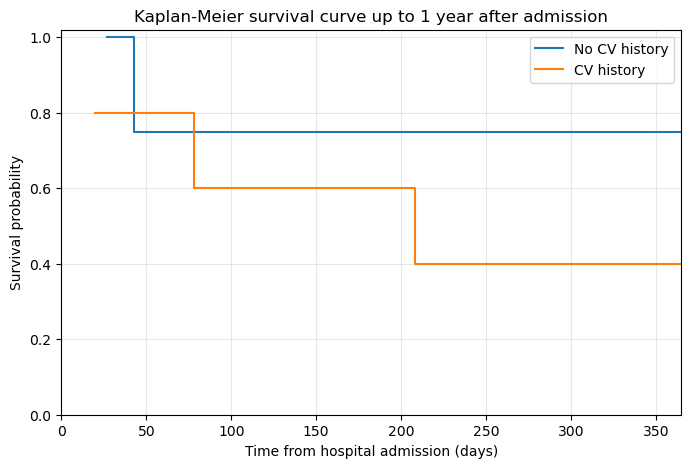

In [12]:
import matplotlib.pyplot as plt
from sksurv.nonparametric import kaplan_meier_estimator

df_pd = df_surv_km.select([
    "patient_id",
    "time_to_event_1y_days",
    "event_1y",
    "cv_history"
]).to_pandas()

plt.figure(figsize=(8, 5))

for group_value, group_df in df_pd.groupby("cv_history"):

    time, survival_prob = kaplan_meier_estimator(
        group_df["event_1y"].astype(bool),
        group_df["time_to_event_1y_days"]
    )

    label = "CV history" if group_value == 1 else "No CV history"

    plt.step(
        time,
        survival_prob,
        where="post",
        label=label
    )

plt.xlim(0, 365)
plt.ylim(0, 1.02)

plt.xlabel("Time from hospital admission (days)")
plt.ylabel("Survival probability")
plt.title("Kaplan-Meier survival curve up to 1 year after admission")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()